# NLP - Clase 2: Tokenización, Embeddings y Clasificación Multiclase

En la clase anterior trabajamos con frases simples, el dataset Sarcasm e IMDB (clasificación **binaria**).

Hoy usamos el dataset **Reuters** de Keras: noticias de agencia clasificadas en **46 categorías**.
Los conceptos son los mismos, pero ahora la salida es **multiclase** (softmax en lugar de sigmoid).

---

## 1. Tokenización básica — Recordatorio rápido

Antes de cargar Reuters, repasamos los bloques fundamentales con frases propias.

In [59]:
from tensorflow.keras.preprocessing.text import Tokenizer

frases = [
    "El banco central subió los tipos de interés",
    "El banco del río estaba inundado",
    "Los mercados reaccionaron a la subida de tipos"
]

tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(frases)
word_index = tokenizer.word_index
print(word_index)

{'<OOV>': 1, 'el': 2, 'banco': 3, 'los': 4, 'tipos': 5, 'de': 6, 'central': 7, 'subió': 8, 'interés': 9, 'del': 10, 'río': 11, 'estaba': 12, 'inundado': 13, 'mercados': 14, 'reaccionaron': 15, 'a': 16, 'la': 17, 'subida': 18}


In [60]:
# Convertir frases a secuencias de índices
secuencias = tokenizer.texts_to_sequences(frases)
for frase, seq in zip(frases, secuencias):
    print(f'{frase}')
    print(f'  → {seq}')

El banco central subió los tipos de interés
  → [2, 3, 7, 8, 4, 5, 6, 9]
El banco del río estaba inundado
  → [2, 3, 10, 11, 12, 13]
Los mercados reaccionaron a la subida de tipos
  → [4, 14, 15, 16, 17, 18, 6, 5]


In [61]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# padding='post' → rellena al final  |  padding='pre' → rellena al principio
padded = pad_sequences(secuencias, maxlen=8, padding='post', truncating='post')
print('Shape:', padded.shape)
print(padded)

Shape: (3, 8)
[[ 2  3  7  8  4  5  6  9]
 [ 2  3 10 11 12 13  0  0]
 [ 4 14 15 16 17 18  6  5]]


In [62]:
# Prueba con frases nuevas (algunas palabras serán <OOV>)
frases_test = [
    "Los bancos centrales controlan la inflación",
    "El río se desbordó esta mañana"
]
seq_test = tokenizer.texts_to_sequences(frases_test)
print('Secuencias test:', seq_test)
# ¿Cuántos tokens son <OOV> (índice 1)?

Secuencias test: [[4, 1, 1, 1, 17, 1], [2, 11, 1, 1, 1, 1]]


---
## 2. Cargando el dataset Reuters

**Reuters-21578** contiene ~11.000 noticias de agencia etiquetadas en 46 temas (economía, política, deportes, etc.).

- Es un problema de **clasificación multiclase**
- Ya viene tokenizado en Keras (igual que IMDB)
- `num_words` controla el vocabulario como ayer

In [63]:
import numpy as np
from tensorflow.keras.datasets import reuters

vocab_size = 10000

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=vocab_size)

print(f'Muestras de entrenamiento: {len(train_data)}')
print(f'Muestras de test:          {len(test_data)}')
print(f'Número de categorías:      {len(set(train_labels))}')
print(f'Ejemplo - primera noticia (índices): {train_data[0][:20]}...')
print(f'Etiqueta de esa noticia: {train_labels[0]}')

Muestras de entrenamiento: 8982
Muestras de test:          2246
Número de categorías:      46
Ejemplo - primera noticia (índices): [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7]...
Etiqueta de esa noticia: 3


In [64]:
# Decodificar una noticia a texto
word_index = reuters.get_word_index()

# El índice interno está desplazado +3 (reservados: padding, OOV, start)
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<OOV>'

def decode_review(sequence):
    return ' '.join(reverse_word_index.get(i, '?') for i in sequence)

print('Noticia 0:')
print(decode_review(train_data[0]))

Noticia 0:
<START> <OOV> <OOV> said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In [65]:
# Distribución de longitudes de noticias
longitudes = [len(s) for s in train_data]
print(f'Longitud mínima:  {min(longitudes)}')
print(f'Longitud máxima:  {max(longitudes)}')
print(f'Longitud media:   {np.mean(longitudes):.1f}')
print(f'Percentil 90:     {np.percentile(longitudes, 90):.0f}')
# Usaremos maxlen basándonos en estos datos

Longitud mínima:  13
Longitud máxima:  2376
Longitud media:   145.5
Percentil 90:     313


In [66]:
# Distribución de categorías
from collections import Counter

conteo = Counter(train_labels)
print('Top 10 categorías más frecuentes:')
for cat, n in conteo.most_common(10):
    print(f'  Categoría {cat:2d}: {n:4d} noticias')

Top 10 categorías más frecuentes:
  Categoría  3: 3159 noticias
  Categoría  4: 1949 noticias
  Categoría 19:  549 noticias
  Categoría 16:  444 noticias
  Categoría  1:  432 noticias
  Categoría 11:  390 noticias
  Categoría 20:  269 noticias
  Categoría 13:  172 noticias
  Categoría  8:  139 noticias
  Categoría 10:  124 noticias


---
## 3. Preparación de datos: Padding y One-Hot Encoding

Dos diferencias clave respecto a ayer:
1. **Las secuencias** → igual que IMDB, aplicamos `pad_sequences`
2. **Las etiquetas** → ya no son 0/1, son 0–45. Necesitamos **one-hot encoding** para `categorical_crossentropy`

In [67]:
# Parámetros (igual que ayer, ajusta maxlen según el análisis de longitudes)
#max_length = 200
max_length = 100
embedding_dim = 16
trunc_type = 'post'
padding_type = 'post'

# Padding de secuencias
train_padded = pad_sequences(train_data, maxlen=max_length,
                             padding=padding_type, truncating=trunc_type)
test_padded  = pad_sequences(test_data,  maxlen=max_length,
                             padding=padding_type, truncating=trunc_type)

print('Train shape:', train_padded.shape)
print('Test shape: ', test_padded.shape)

Train shape: (8982, 100)
Test shape:  (2246, 100)


In [68]:
import tensorflow as tf

num_classes = 46

# One-hot encoding de las etiquetas
train_labels_oh = tf.keras.utils.to_categorical(train_labels, num_classes=num_classes)
test_labels_oh  = tf.keras.utils.to_categorical(test_labels,  num_classes=num_classes)

print('Shape etiquetas train:', train_labels_oh.shape)
print('Etiqueta original:', train_labels[0], '→ one-hot:', train_labels_oh[0])

Shape etiquetas train: (8982, 46)
Etiqueta original: 3 → one-hot: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


---
## 4. Construcción del modelo

La arquitectura es igual que ayer, **con dos cambios**:
- Última capa: `Dense(46, activation='softmax')` en lugar de `Dense(1, activation='sigmoid')`
- Loss: `categorical_crossentropy` en lugar de `binary_crossentropy`

In [69]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # 46 clases
])

model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print('Modelo compilado ✓')

Modelo compilado ✓


In [71]:
num_epochs = 10

history = model.fit(
    train_padded, train_labels_oh,
    epochs=num_epochs,
    batch_size=32,
    validation_data=(test_padded, test_labels_oh),
    verbose=1
)

Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4229 - loss: 2.4442 - val_accuracy: 0.6300 - val_loss: 1.5413
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6828 - loss: 1.3310 - val_accuracy: 0.7182 - val_loss: 1.2044
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8196 - loss: 0.7966 - val_accuracy: 0.7449 - val_loss: 1.0700
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8940 - loss: 0.4620 - val_accuracy: 0.7427 - val_loss: 1.0616
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9403 - loss: 0.2823 - val_accuracy: 0.7458 - val_loss: 1.1106
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9531 - loss: 0.1989 - val_accuracy: 0.7418 - val_loss: 1.1710
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9597 - loss: 0.1516 - val_accuracy: 0.7507 - val_loss: 1.1805
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9573 - loss: 0.1406 - val_accuracy: 0.

---
## 5. Visualización del entrenamiento

Una novedad respecto a ayer: representamos las curvas de **loss** y **accuracy** para ver si el modelo aprende bien o hay overfitting.

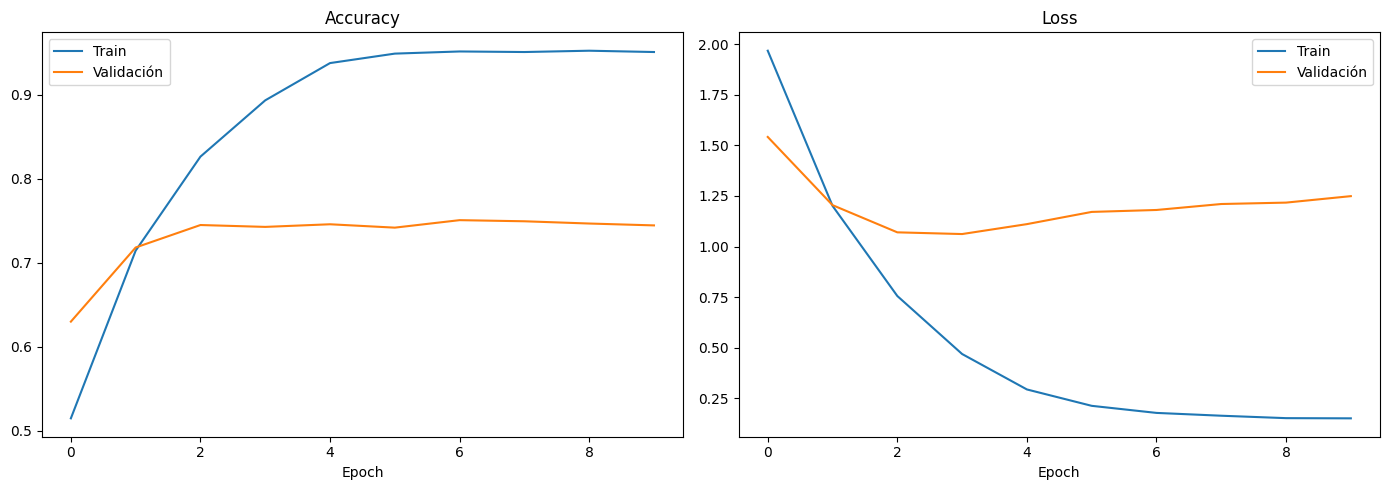

In [72]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validación')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validación')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

---
## 6. Exportar embeddings para visualización

Igual que ayer: exportamos `vecs.tsv` y `meta.tsv` para el **Embedding Projector** de TensorFlow.

🔗 https://projector.tensorflow.org/

In [73]:
embedding_layer   = model.layers[0]
embedding_weights = embedding_layer.get_weights()[0]

print('Shape de la matriz de embeddings:', embedding_weights.shape)
# (vocab_size, embedding_dim) → 10000 palabras × 16 dimensiones

Shape de la matriz de embeddings: (10000, 16)


In [74]:
reverse_wi = {v: k for k, v in word_index.items()}

import io

out_v = io.open('vecs_reuters.tsv', 'w', encoding='utf-8')
out_m = io.open('meta_reuters.tsv', 'w', encoding='utf-8')

for word_num in range(1, vocab_size):
    word_name      = reverse_wi.get(word_num, f'word_{word_num}')
    word_embedding = embedding_weights[word_num]
    out_m.write(word_name + '\n')
    out_v.write('\t'.join([str(x) for x in word_embedding]) + '\n')

out_v.close()
out_m.close()
print('Archivos exportados: vecs_reuters.tsv  y  meta_reuters.tsv ✓')

Archivos exportados: vecs_reuters.tsv  y  meta_reuters.tsv ✓


In [75]:
try:
    from google.colab import files
except ImportError:
    pass
else:
    files.download('vecs_reuters.tsv')
    files.download('meta_reuters.tsv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 🧪 Ejercicios propuestos

1. **Cambia `max_length`** a 100 y a 300. ¿Cómo afecta a la accuracy?
2. **Cambia `embedding_dim`** a 32. ¿Mejora o empeora?
3. **Añade una segunda capa `Dense`** antes de la salida. ¿Cambia el resultado?
4. ¿En qué epoch empieza el **overfitting**? ¿Cómo lo detectas en las gráficas?
5. **Opcional**: Prueba a usar `sparse_categorical_crossentropy` con las etiquetas originales (sin one-hot encoding). ¿Es equivalente?


In [76]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN INICIAL ---
vocab_size = 10000
num_classes = 46
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=vocab_size)

# One-hot encoding de etiquetas (para categorical_crossentropy)
train_labels_oh = tf.keras.utils.to_categorical(train_labels, num_classes)
test_labels_oh = tf.keras.utils.to_categorical(test_labels, num_classes)

def build_and_train(max_len, embed_dim, extra_dense=False, use_sparse=False, epochs=10):
    """Función para crear y entrenar el modelo según parámetros"""

    # 1. Preparación de secuencias
    x_train = pad_sequences(train_data, maxlen=max_len, padding='post', truncating='post')
    x_test = pad_sequences(test_data, maxlen=max_len, padding='post', truncating='post')

    # 2. Arquitectura
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Embedding(vocab_size, embed_dim, input_length=max_len))
    model.add(tf.keras.layers.Flatten())

    if extra_dense:
        model.add(tf.keras.layers.Dense(32, activation='relu')) # Capa extra del ejercicio 3

    model.add(tf.keras.layers.Dense(32, activation='relu')) # Capa del modelo original
    model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

    # 3. Compilación
    loss_fn = 'sparse_categorical_crossentropy' if use_sparse else 'categorical_crossentropy'
    y_train = train_labels if use_sparse else train_labels_oh
    y_test = test_labels if use_sparse else test_labels_oh

    model.compile(loss=loss_fn, optimizer='adam', metrics=['accuracy'])

    # 4. Entrenamiento
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=32,
                        validation_data=(x_test, y_test), verbose=0)

    final_acc = max(history.history['val_accuracy'])

    # NUEVO: Extraemos el número total de parámetros del modelo
    total_params = model.count_params()

    # NUEVO: Devolvemos también los parámetros
    return final_acc, history, total_params

# --- EJECUCIÓN DE EXPERIMENTOS ---

# Ejercicio 1: Comparar max_length (Original 200 vs 100 vs 300)
acc_100, _, _ = build_and_train(max_len=100, embed_dim=16)
acc_200, hist_orig, params_orig = build_and_train(max_len=200, embed_dim=16)
acc_300, _, _ = build_and_train(max_len=300, embed_dim=16)

# Ejercicio 2: Cambiar embedding_dim a 32 (manteniendo max_len=200)
acc_embed32, _, params_32 = build_and_train(max_len=200, embed_dim=32)

# Ejercicio 3: Añadir capa Dense extra
acc_extra_layer, _, _ = build_and_train(max_len=200, embed_dim=16, extra_dense=True)

# Ejercicio 5: Sparse Categorical Crossentropy
acc_sparse, _, _ = build_and_train(max_len=200, embed_dim=16, use_sparse=True)

# --- COMPARATIVA FINAL ---
print("\n" + "="*50)
print("RESULTADOS DE ACCURACY MAX (Validación Accuracy)")
print("="*50)
print(f"Original (Len:200, Emb:16): {acc_200:.4f}")
print(f"Ejer 1 - Len 100:           {acc_100:.4f}")
print(f"Ejer 1 - Len 300:           {acc_300:.4f}")
print(f"Ejer 2 - Emb Dim 32:        {acc_embed32:.4f}")
print(f"Ejer 3 - Capa Dense Extra:  {acc_extra_layer:.4f}")
print(f"Ejer 5 - Sparse Crossent.:  {acc_sparse:.4f}")
print("="*50)


RESULTADOS DE ACCURACY MAX (Validación Accuracy)
Original (Len:200, Emb:16): 0.7467
Ejer 1 - Len 100:           0.7467
Ejer 1 - Len 300:           0.7378
Ejer 2 - Emb Dim 32:        0.7529
Ejer 3 - Capa Dense Extra:  0.7351
Ejer 5 - Sparse Crossent.:  0.7413


### **Cambia `max_length`** a 100 y a 300. ¿Cómo afecta a la accuracy?


Aunque es una apreciación minuscula ya que no varia mucho el val_accuaracy, nos damos cuenta que nuestro módelo es más eficiente con 100 de max_length debido a que al usar Flatten(), multiplicamos max_length por embedding_dim, al rellenar las noticias con 0, la red se puede volver perezosa o confundirse

### **Cambia `embedding_dim`** a 32. ¿Mejora o empeora? ¿Cuántos parámetros nuevos añade?


También la apreciación es minuscula, pero mejora algo con 32. Como tenemos 46 categorías, esa resolución extra ayudó a separar mejor los conceptos.

In [78]:
print("\n" + "="*50)
print("ANÁLISIS DE PARÁMETROS (Ejercicio 2)")
print("="*50)
print(f"Parámetros modelo original (emb=16): {params_orig:,}")
print(f"Parámetros modelo modificado (emb=32): {params_32:,}")
print("-" * 50)
print(f"Diferencia: Se añaden {params_32 - params_orig:,} parámetros nuevos.")
print("="*50)


ANÁLISIS DE PARÁMETROS (Ejercicio 2)
Parámetros modelo original (emb=16): 263,950
Parámetros modelo modificado (emb=32): 526,350
--------------------------------------------------
Diferencia: Se añaden 262,400 parámetros nuevos.


### **Añade una segunda capa `Dense`** antes de la salida. ¿Cambia el resultado?


Añadir capas densas nos ayudo a procesar mejor las relaciones complejas, pero en este modelo (que usamos un Flatten muy básico), el factor limitante suele ser cómo representamos las palabras inicialmente (el embedding) más que cuántas capas de procesamiento hay después.

### ¿En qué epoch empieza el **overfitting**? ¿Cómo lo detectas en las gráficas?

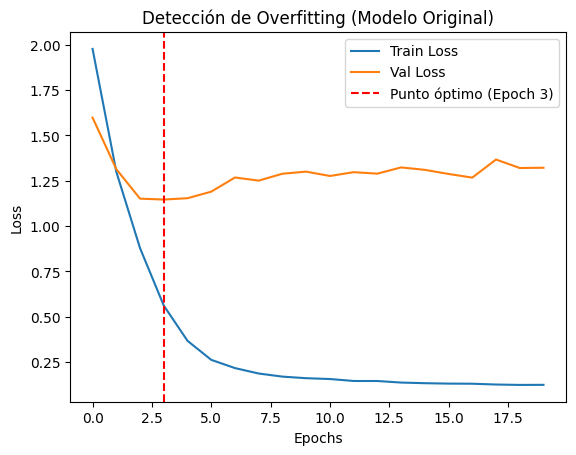

In [77]:
# Visualización del Overfitting (Ejercicio 4)

_, hist_ejer4, _ = build_and_train(max_len=200, embed_dim=16, epochs=20)

# 1. Extraemos las listas de pérdidas
train_loss = hist_ejer4.history['loss']
val_loss = hist_ejer4.history['val_loss']

# 2. Calculamos dinámicamente el momento del overfitting (el valor mínimo de val_loss)
mejor_epoca = val_loss.index(min(val_loss))

# 3. Visualización
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')

# Añadimos la línea en la época calculada dinámicamente
plt.axvline(x=mejor_epoca, color='red', linestyle='--',
            label=f'Punto óptimo (Epoch {mejor_epoca})')

plt.title('Detección de Overfitting (Modelo Original)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

El overfitting empieza oficialmente en la Epoch 3 (que es el cuarto ciclo de entrenamiento, ya que empezamos a contar desde 0).

Tienes que fijarte en el momento de "divorcio" de las lineas, en la Epoch 3 el Val Loss es el punto más bajo, el Train Loss empieza a caer en picado y el Val Loss apartir de ahí empieza a subir.

Esto indica que el modelo ya no está aprendiendo patrones generales, sino que está memorizando el ruido y los detalles específicos de tus datos de entrenamiento.

### **Opcional**: Prueba a usar `sparse_categorical_crossentropy` con las etiquetas originales (sin one-hot encoding). ¿Es equivalente? ¿Es necesario aplicar to_categorical a las etiquetas?

El cambio es solo estructural y no hay diferencia, la diferencia de decimales se debe simplemente a que los pesos iniciales de la red se generan al azar cada vez que empiezas de cero.

No, al usar sparse_categorical_crossentropy ya no es necesario aplicar to_categorical porque esta función de pérdida espera que las etiquetas sean números enteros